## Preprocessing Precinct Boundaries

In [1]:
import pandas as pd
import pygris
import geopandas
import topojson as tp
import maup
import json

from shapely.geometry import shape

### Arkansas Precinct Boundary Path

#### CVAP Census Data Estimates

In [2]:
path = '../../data/Arkansas/ar-cb-CVAP.csv'

In [3]:
cb_df = pd.read_csv(path)
cb_df

,geoname,lntitle,geoid,lnnumber,cit_est,cit_moe,cvap_est,cvap_moe
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,1,486,149,409,103
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,2,444,131,391,106
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,3,0,13,0,13
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,4,0,13,0,13
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,5,7,6,0,13
...,...,...,...,...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,9,0,15,0,15
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,10,0,15,0,15
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,11,0,15,0,15
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,12,0,15,0,15


In [ ]:
cb_df = cb_df[['geoname', 'lntitle', 'geoid', 'cvap_est']]
relevant_groups = ['Total', 'Black or African American Alone', 'White Alone', 'Hispanic or Latino']
cb_df = cb_df[cb_df['lntitle'].isin(relevant_groups)]
cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Not Hispanic or Latino,1500000US010010201001,391
2,"Block Group 1, Census Tract 201, Autauga Count...",American Indian or Alaska Native Alone,1500000US010010201001,0
3,"Block Group 1, Census Tract 201, Autauga Count...",Asian Alone,1500000US010010201001,0
4,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
...,...,...,...,...
3149856,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Asian and White,1500000US721537506022,0
3149857,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Black or African American and White,1500000US721537506022,0
3149858,"Block Group 2, Census Tract 7506.02, Yauco Mun...",American Indian or Alaska Native and Black or ...,1500000US721537506022,0
3149859,"Block Group 2, Census Tract 7506.02, Yauco Mun...",Remainder of Two or More Race Responses,1500000US721537506022,0


In [ ]:
grouped = (
    cb_df[cb_df['lntitle'] != 'Total']
    .groupby(['geoid', 'geoname'])['cvap_est']
    .sum()
    .reset_index()
)

totals = cb_df[cb_df['lntitle'] == 'Total'][['geoid', 'geoname', 'cvap_est']]

merged = totals.merge(
    grouped,
    on=['geoid', 'geoname'],
    suffixes=('_Total', '_Known')
)

merged['Other'] = merged['cvap_est_Total'] - merged['cvap_est_Known']

other_rows = merged[['geoid', 'geoname', 'Other']].rename(columns={'Other': 'cvap_est'})
other_rows['lntitle'] = 'Other'

cb_df = pd.concat(
    [cb_df, other_rows[['geoid', 'geoname', 'lntitle', 'cvap_est']]],
    ignore_index=True
)

cb_df = cb_df.sort_values(by='geoname')

cb_df

,geoname,lntitle,geoid,cvap_est
0,"Block Group 1, Census Tract 201, Autauga Count...",Total,1500000US010010201001,409
1,"Block Group 1, Census Tract 201, Autauga Count...",Black or African American Alone,1500000US010010201001,0
2,"Block Group 1, Census Tract 201, Autauga Count...",White Alone,1500000US010010201001,358
3,"Block Group 1, Census Tract 201, Autauga Count...",Hispanic or Latino,1500000US010010201001,18
4,"Block Group 2, Census Tract 201, Autauga Count...",Total,1500000US010010201002,909
...,...,...,...,...
1211480,"Block Group 1, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506011,0
1211481,"Block Group 2, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506012,0
1211482,"Block Group 3, Census Tract 7506.01, Yauco Mun...",Other,1500000US721537506013,0
1211483,"Block Group 1, Census Tract 7506.02, Yauco Mun...",Other,1500000US721537506021,0


##### Only Arkansas

In [ ]:
ar_cb = cb_df[cb_df['geoname'].str.endswith('Arkansas')]
ar_cb.drop(columns='geoname', inplace=True)
ar_cb['COUNTYFP'] = ar_cb['geoid'].str.extract(r'1500000US05(\d{3})')
ar_cb = ar_cb.sort_values(by=['COUNTYFP', 'geoid'])
ar_cb

,geoname,lntitle,geoid,cvap_est
44258,"Block Group 1, Census Tract 1, Sebastian Count...",White Alone,1500000US051310001001,128
44257,"Block Group 1, Census Tract 1, Sebastian Count...",Black or African American Alone,1500000US051310001001,233
44259,"Block Group 1, Census Tract 1, Sebastian Count...",Hispanic or Latino,1500000US051310001001,155
44256,"Block Group 1, Census Tract 1, Sebastian Count...",Total,1500000US051310001001,593
980252,"Block Group 1, Census Tract 1, Sebastian Count...",Other,1500000US051310001001,77
...,...,...,...,...
978791,"Block Group 7, Census Tract 3, Craighead Count...",Other,1500000US050310003007,7
38415,"Block Group 7, Census Tract 3, Craighead Count...",Hispanic or Latino,1500000US050310003007,0
38412,"Block Group 7, Census Tract 3, Craighead Count...",Total,1500000US050310003007,924
38413,"Block Group 7, Census Tract 3, Craighead Count...",Black or African American Alone,1500000US050310003007,0


#### NYT Precinct Election Data

In [12]:
nyt_path = '../../data/Arkansas/fixed_nyt-ar-precinct.geojson'

In [13]:
nyt_gdf = geopandas.read_file(nyt_path)
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,pct_dem_lead,official_boundary,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,-0.3638,True,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,-0.2121,True,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,-0.5744,True,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,0.2395,True,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,-0.7256,True,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,-0.2166,True,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,-0.6250,True,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,AR,05149-29 - Ions Creek,0,19,19,-1.0000,True,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,AR,05149-24 - Waveland,18,69,88,-0.5795,True,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


In [ ]:
nyt_gdf = nyt_gdf[['state', 'GEOID', 'votes_dem', 'votes_rep', 'votes_total', 'geometry']]
nyt_gdf['COUNTYFP'] = nyt_gdf['GEOID'].str.extract(r'^..(\d{3})')
nyt_gdf

,state,GEOID,votes_dem,votes_rep,votes_total,geometry
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...
2676,AR,05149-10 - Dardanelle Ward 3,59,93,157,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,AR,05149-18 - Magazine 1,79,354,440,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,AR,05149-29 - Ions Creek,0,19,19,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,AR,05149-24 - Waveland,18,69,88,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


#### Merge

In [17]:
nyt_df = nyt_gdf
cvap_df = ar_cb

In [18]:
cvap_df["bg_geoid"] = cvap_df["geoid"].str.replace("1500000US", "")
cvap_df

,lntitle,geoid,cvap_est,COUNTYFP,bg_geoid
36811,Hispanic or Latino,1500000US050014801001,0,001,050014801001
36809,Black or African American Alone,1500000US050014801001,98,001,050014801001
978390,Other,1500000US050014801001,20,001,050014801001
36808,Total,1500000US050014801001,811,001,050014801001
36810,White Alone,1500000US050014801001,693,001,050014801001
...,...,...,...,...,...
45983,Hispanic or Latino,1500000US051499526003,19,149,051499526003
45982,White Alone,1500000US051499526003,774,149,051499526003
980683,Other,1500000US051499526003,0,149,051499526003
45980,Total,1500000US051499526003,793,149,051499526003


In [20]:
race_map = {
    "Total"                              : "cvap_total",
    "White Alone"                        : "cvap_white",
    "Black or African American Alone"    : "cvap_black",
    "Hispanic or Latino"                 : "cvap_hispanic",
    "Other"                              : "cvap_other",
}

cvap_filtered = cvap_df[cvap_df["lntitle"].isin(race_map)].copy()
cvap_filtered["lntitle"] = cvap_filtered["lntitle"].map(race_map)
cvap_filtered

,lntitle,geoid,cvap_est,COUNTYFP,bg_geoid
36811,cvap_hispanic,1500000US050014801001,0,001,050014801001
36809,cvap_black,1500000US050014801001,98,001,050014801001
978390,cvap_other,1500000US050014801001,20,001,050014801001
36808,cvap_total,1500000US050014801001,811,001,050014801001
36810,cvap_white,1500000US050014801001,693,001,050014801001
...,...,...,...,...,...
45983,cvap_hispanic,1500000US051499526003,19,149,051499526003
45982,cvap_white,1500000US051499526003,774,149,051499526003
980683,cvap_other,1500000US051499526003,0,149,051499526003
45980,cvap_total,1500000US051499526003,793,149,051499526003


In [21]:
cvap_wide = (
    cvap_filtered
    .pivot_table(index="bg_geoid", columns="lntitle", values="cvap_est", aggfunc="sum")
    .reset_index()
)
cvap_wide.columns.name = None
cvap_wide

,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050014801001,98,0,20,811,693
1,050014802001,46,61,7,1153,1039
2,050014803001,362,7,0,656,287
3,050014803002,180,0,10,1343,1153
4,050014804001,772,0,45,999,182
...,...,...,...,...,...,...
2289,051499525003,5,54,13,480,408
2290,051499525004,0,22,0,785,763
2291,051499526001,0,22,6,613,585
2292,051499526002,7,6,36,418,369


### Obtain Census Block Data using `pygris`

In [22]:
bg = pygris.block_groups(state='AR', year=2020)
bg = bg[["GEOID", "geometry"]].copy()        

bg = bg.merge(cvap_wide, left_on="GEOID", right_on="bg_geoid", how="left")
bg

Using FIPS code '05' for input 'AR'


,GEOID,geometry,bg_geoid,cvap_black,cvap_hispanic,cvap_other,cvap_total,cvap_white
0,050310011011,"POLYGON ((-90.64716 35.91775, -90.64714 35.917...",050310011011,0,9,34,1811,1768
1,050310011022,"POLYGON ((-90.58719 35.9297, -90.58694 35.9301...",050310011022,0,0,30,574,544
2,050310011021,"POLYGON ((-90.56687 35.87831, -90.56416 35.878...",050310011021,0,0,0,523,523
3,050310004041,"POLYGON ((-90.68694 35.78915, -90.68646 35.789...",050310004041,517,202,85,2223,1419
4,050310004031,"POLYGON ((-90.7027 35.82138, -90.70236 35.8213...",050310004031,35,0,52,1096,1009
...,...,...,...,...,...,...,...,...
2289,050634901023,"POLYGON ((-91.66623 35.8463, -91.66618 35.8463...",050634901023,0,24,24,748,700
2290,050634901021,"POLYGON ((-91.59292 35.8246, -91.59276 35.8249...",050634901021,0,32,10,1046,1004
2291,050634903005,"POLYGON ((-91.64259 35.78524, -91.64253 35.785...",050634903005,0,32,55,589,502
2292,050070205031,"POLYGON ((-94.19751 36.33631, -94.19749 36.337...",050070205031,14,134,67,629,414


### Proate Population Blocks -> Precincts

In [24]:
precincts = geopandas.GeoDataFrame(nyt_gdf, geometry="geometry")
blocks = geopandas.GeoDataFrame(bg, geometry="geometry")

In [25]:
# change to CRS for blocks / was orignally in GPS
precincts = precincts.to_crs(precincts.estimate_utm_crs())
blocks = blocks.to_crs(blocks.estimate_utm_crs())
print(precincts.crs)
print(blocks.crs)

EPSG:32615
EPSG:32615


In [29]:
invalid_mask = ~precincts.is_valid

print(f"Number of invalid geometries: {invalid_mask.sum()}")

from shapely.validation import explain_validity
if invalid_mask.any():
    print(precincts[invalid_mask].geometry.apply(explain_validity))

Number of invalid geometries: 0


In [30]:
print(f"Nulls found: {precincts.geometry.isna().sum()}")
print(f"Empty shapes found: {precincts.geometry.is_empty.sum()}")

Nulls found: 0
Empty shapes found: 0


In [31]:
from gerrychain import Graph
import networkx as nx

graph = Graph.from_geodataframe(
    precincts,
    adjacency='queen'
)
G = graph
#check if the precicnts are connected
print(nx.is_connected(G))

True


In [32]:
demo_col = ['cvap_white', 'cvap_black','cvap_hispanic','cvap_other','cvap_total']

In [33]:
pieces = maup.intersections(blocks, precincts, area_cutoff=0)
print("Number of intersection pieces:", len(pieces))

weights = pieces.area / pieces.index.get_level_values(0).map(blocks.area)
aggregated_prorate = maup.prorate(pieces, blocks[demo_col], weights)
aggregated_prorate = aggregated_prorate.reindex(precincts.index, fill_value=0)

print("Zero population after prorate:", 
      (aggregated_prorate["cvap_total"] == 0).sum())

Number of intersection pieces: 13356
Zero population after prorate: 0


In [34]:
precincts["White_population"] = aggregated_prorate["cvap_white"].values
precincts["Black_population"] = aggregated_prorate["cvap_black"].values
precincts["Latino_population"] = aggregated_prorate["cvap_hispanic"].values
precincts["Other_population"] = aggregated_prorate["cvap_other"].values
precincts["Total_population"] = aggregated_prorate["cvap_total"].values

In [35]:
cvap_cols = [c for c in precincts.columns if c.endswith("_population")]

for col in [c for c in cvap_cols if c != "cvap_total"]:
    precincts[f"{col.replace('_population', '')}_percentage"] = (
        precincts[col] / precincts["Total_population"]
    )

In [36]:
precincts.head()

,state,GEOID,votes_dem,votes_rep,votes_total,geometry,COUNTYFP,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,Total_percentage
0,AR,05001-81 - Stuttgart 2,293,639,951,"MULTIPOLYGON (((635621.038 3816237.2, 635621.7...",001,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,1.0
1,AR,05001-36 - Gillett Ward 3,25,39,66,"POLYGON ((648540.76 3776211.027, 648538.959 37...",001,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,1.0
2,AR,05001-53 - Dewitt 2,49,188,242,"POLYGON ((653803.262 3794725.095, 653803.256 3...",001,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,1.0
3,AR,05001-51 - DeWitt 1,101,61,167,"POLYGON ((653803.262 3794725.095, 653808.455 3...",001,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,1.0
4,AR,05001-55 - Dewitt 3,42,272,317,"POLYGON ((652703.83 3796891.285, 652703.43 379...",001,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,1.0


### Final Cleanup

In [37]:
precincts["name"] = precincts["GEOID"]
precincts['votes_other'] = precincts['votes_total'] - precincts['votes_rep'] - precincts['votes_dem']

In [38]:
ar_precincts = precincts.drop(columns=['state', 'GEOID', 'Total_percentage'])
ar_precincts.columns

Index(['votes_dem', 'votes_rep', 'votes_total', 'geometry', 'COUNTYFP',
       'White_population', 'Black_population', 'Latino_population',
       'Other_population', 'Total_population', 'White_percentage',
       'Black_percentage', 'Latino_percentage', 'Other_percentage', 'name',
       'votes_other'],
      dtype='object')

In [39]:
cols = [
    "name", "COUNTYFP",
    "votes_dem", "votes_rep", "votes_other", "votes_total",
    "White_population", "Black_population", "Latino_population", "Other_population", "Total_population",
    "White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage",
    "geometry"
]

ar_precincts = ar_precincts[cols]
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((635621.038 3816237.2, 635621.7..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((648540.76 3776211.027, 648538.959 37..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((653803.262 3794725.095, 653803.256 3..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((653803.262 3794725.095, 653808.455 3..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((652703.83 3796891.285, 652703.43 379..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((485442.696 3896709.11, 485486.865 38..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341,0.869636,0.000000,0.078865,0.051499,"POLYGON ((467222.738 3896770.73, 467221.004 38..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048,0.882775,0.016746,0.014356,0.086123,"POLYGON ((455838.831 3844740.179, 455914.383 3..."
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662,0.920831,0.027457,0.016164,0.035547,"POLYGON ((439620.094 3889681.729, 439619.699 3..."


In [40]:
ar_precincts = geopandas.GeoDataFrame(ar_precincts, geometry='geometry')
ar_precincts = ar_precincts.set_crs("EPSG:32615", allow_override=True)
ar_precincts = ar_precincts.to_crs("EPSG:4326") 
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341,0.869636,0.000000,0.078865,0.051499,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048,0.882775,0.016746,0.014356,0.086123,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662,0.920831,0.027457,0.016164,0.035547,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


<Axes: >

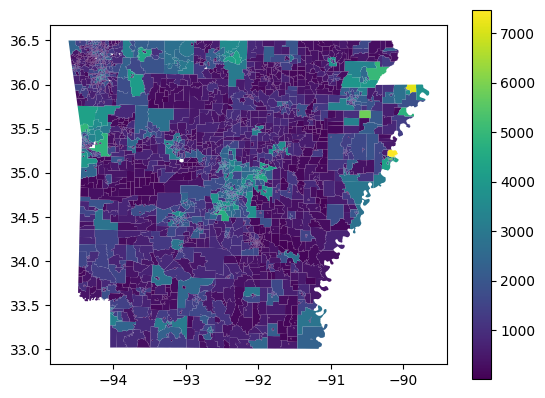

In [43]:
ar_precincts.plot('Total_population', legend=True)

### Exports

#### To Seawulf

In [44]:
final = ar_precincts.rename(columns={
    "name"           : "Unique_ID",
    "votes_dem"      : "Kamala D. Harris",
    "votes_rep"      : "Donald J. Trump",
    "votes_other"    : "Other_candidates",
    "votes_total"    : "Total_votes",
    "geometry"       : "geometry"
})

final = final.drop(columns=["White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage"])
final

,Unique_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


In [45]:
final.to_file("../output/Arkansas/seawulf.gpkg", driver="GPKG")

#### To Application

In [46]:
ar_precincts

,name,COUNTYFP,votes_dem,votes_rep,votes_other,votes_total,White_population,Black_population,Latino_population,Other_population,Total_population,White_percentage,Black_percentage,Latino_percentage,Other_percentage,geometry
0,05001-81 - Stuttgart 2,001,293,639,19,951,486.169395,356.604974,32.728840,0.738939,876.242147,0.554835,0.406971,0.037351,0.000843,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,001,25,39,2,66,63.524419,10.565301,0.982819,2.213607,77.286145,0.821938,0.136704,0.012717,0.028642,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,001,49,188,5,242,230.348940,133.055168,0.119868,4.781286,368.305262,0.625429,0.361263,0.000325,0.012982,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,001,101,61,5,167,332.713262,201.772191,0.000000,7.098115,541.583568,0.614334,0.372560,0.000000,0.013106,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,001,42,272,3,317,36.167855,9.010094,0.713321,0.281977,46.173247,0.783308,0.195137,0.015449,0.006107,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,149,59,93,5,157,242.266509,33.762641,53.156670,23.501428,352.687248,0.686916,0.095730,0.150719,0.066635,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,149,79,354,7,440,763.775521,0.000000,69.265079,45.229741,878.270341,0.869636,0.000000,0.078865,0.051499,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,05149-29 - Ions Creek,149,0,19,0,19,141.627233,2.686700,2.303132,13.816984,160.434048,0.882775,0.016746,0.014356,0.086123,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,05149-24 - Waveland,149,18,69,1,88,253.978789,7.573110,4.458375,9.804388,275.814662,0.920831,0.027457,0.016164,0.035547,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


In [47]:
precincts = ar_precincts[['name', 'Total_population',
       "White_percentage", "Black_percentage", "Latino_percentage", "Other_percentage",
       'geometry']]
precincts['GEOID'] = precincts['name']
precincts['total_population'] = precincts['Total_population']
precincts['black_percentage'] = precincts['Black_percentage'] * 100
precincts['latino_percentage'] = precincts['Latino_percentage'] * 100
precincts['other_percentage'] = precincts['Other_percentage'] * 100
precincts = precincts[['GEOID', 'name', 'total_population',
       'black_percentage', 'latino_percentage', 'other_percentage',
       'geometry']]
precincts

,GEOID,name,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,352.687248,9.572969,15.071900,6.663532,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,878.270341,0.000000,7.886533,5.149865,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,160.434048,1.674644,1.435563,8.612252,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,05149-24 - Waveland,05149-24 - Waveland,275.814662,2.745724,1.616439,3.554701,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


In [48]:
cols = {
    'GEOID' : 'GEOID',
    'name' : 'precinct', 
}

precincts = precincts.rename(columns=cols)
precincts

,GEOID,precinct,total_population,black_percentage,latino_percentage,other_percentage,geometry
0,05001-81 - Stuttgart 2,05001-81 - Stuttgart 2,876.242147,40.697081,3.735137,0.084330,"MULTIPOLYGON (((-91.52313 34.47881, -91.52312 ..."
1,05001-36 - Gillett Ward 3,05001-36 - Gillett Ward 3,77.286145,13.670368,1.271662,2.864170,"POLYGON ((-91.38939 34.1162, -91.38947 34.1131..."
2,05001-53 - Dewitt 2,05001-53 - Dewitt 2,368.305262,36.126328,0.032546,1.298186,"POLYGON ((-91.32906 34.28234, -91.32906 34.282..."
3,05001-51 - DeWitt 1,05001-51 - DeWitt 1,541.583568,37.255966,0.000000,1.310622,"POLYGON ((-91.32906 34.28234, -91.329 34.28234..."
4,05001-55 - Dewitt 3,05001-55 - Dewitt 3,46.173247,19.513668,1.544880,0.610693,"POLYGON ((-91.34062 34.30203, -91.34062 34.302..."
...,...,...,...,...,...,...,...
2676,05149-10 - Dardanelle Ward 3,05149-10 - Dardanelle Ward 3,352.687248,9.572969,15.071900,6.663532,"POLYGON ((-93.15995 35.2133, -93.15946 35.2126..."
2677,05149-18 - Magazine 1,05149-18 - Magazine 1,878.270341,0.000000,7.886533,5.149865,"POLYGON ((-93.36013 35.21342, -93.36015 35.213..."
2678,05149-29 - Ions Creek,05149-29 - Ions Creek,160.434048,1.674644,1.435563,8.612252,"POLYGON ((-93.48245 34.74382, -93.48162 34.743..."
2679,05149-24 - Waveland,05149-24 - Waveland,275.814662,2.745724,1.616439,3.554701,"POLYGON ((-93.66288 35.14822, -93.66288 35.148..."


In [50]:
precincts = precincts.to_crs(epsg=4326)
topo = tp.Topology(precincts)

topo.to_json("../output/Arkansas/Arkansas_precincts_topo.topojson")